<h3 align = "center">Assignment 0: Initial Exploration of Training Dataset<h3>

<p align = "center">John Bennett <br>
CS569 Machine Learning <br>
F25 University of Hartford <br>
9/5/25
<p>

#### The exercise for this assignment is to load and perform analysis on the titanic.csv dataset.

---

### Import Dependencies

In [ ]:
import os
import pandas as pd 
from tabulate import tabulate
from IPython.display import display, Latex
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.co

import warnings
warnings.filterwarnings("ignore")

Retrieve Data

In [19]:
# base directory relative to current file
base_dir = os.getcwd() # method necessary for .ipynb files
# print(base_dir)

# generate path
data_path = os.path.join(base_dir, "data", "titanic.csv")
# print(data_path)

df_titanic = pd.read_csv(data_path)

---

### 4.1 Task 1: Load and Inspect the Data:

Function that returns a dict containing head, number of rows/columns, and a summary table including the data from .info() and .describe() as well as 

In [20]:
def dataframe_overview(df):

  df_info = pd.DataFrame({
    'attribute': df.columns,
    'data_type': df.dtypes,
    'num_null': df.isnull().sum(),
    'num_unique': df.nunique()
  })

  stats = df.describe()
  df_stats = stats.T.reset_index(drop = True)
  df_stats["attribute"] = stats.columns
  df_stats.head()
  df_stats = df_stats[[df_stats.columns[-1]] + list(df_stats.columns[:-1])]

  df_summary = df_stats.merge(df_info,
                              on = "attribute",
                              how = "right").drop('count', axis =1)
  
  return {'nrows': df.shape[0],
          'ncolumns': df.shape[1],
          'head': df.head(),
          'summary_table': df_summary}

In [21]:
overview = dataframe_overview(df_titanic)

In [22]:
print(f"Number of Rows: {overview['nrows']}")
print(f"Number of Columns: {overview['ncolumns']}\n\n")

Number of Rows: 891
Number of Columns: 12




In [23]:
overview['head']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

#### Table: Attribute Meaning

| Column        | Description                                                           |
| ------------- | --------------------------------------------------------------------- |
| `PassengerId` | Unique identifier for each passenger.                                 |
| `Survived`    | Survival status (0 = No, 1 = Yes).                                    |
| `Pclass`      | Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd).                          |
| `Name`        | Full name of the passenger.                                           |
| `Sex`         | Gender of the passenger.                                              |
| `Age`         | Age in years.                                                         |
| `SibSp`       | Number of siblings/spouses aboard the Titanic.                        |
| `Parch`       | Number of parents/children aboard the Titanic.                        |
| `Ticket`      | Ticket number.                                                        |
| `Fare`        | Passenger fare (in British pounds).                                   |
| `Cabin`       | Cabin number.                                                         |
| `Embarked`    | Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton). |


---

In [24]:
overview['summary_table']

,attribute,mean,std,min,25%,50%,75%,max,data_type,num_null,num_unique
0,PassengerId,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000,int64,0,891
1,Survived,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000,int64,0,2
2,Pclass,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000,int64,0,3
3,Name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,891
4,Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,2
5,Age,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000,float64,177,88
6,SibSp,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000,int64,0,7
7,Parch,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000,int64,0,7
8,Ticket,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,681
9,Fare,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292,float64,0,248


&nbsp;&nbsp;The summary data reveals a number of notable characteristics. Several of the attributes were imported as data types that are not consistent with what their values represent. The number of unique values for "Survived" and "Pclass" indicate that the data value represent classes rather than measures. All attributes with numeric "data_type" values had aggregate data generated in the summary but this data for "Survived" and "Pclass" are not meaningful and will not factor into downstream analysis. "Ticket" has the greatest variation in values (outside of "PassengerId" which is a unique identifier for each datapoint). Since they are not unique, the variation in values is notable but likely arbitrary and may reflect inconsistencies in reporting. There are three attributes with null values: "Cabin", "Age", and "Embarked". The maximum value for age is less than the number of unique values for this attribute. The minimum value is less than one, potentially identifying passengers under the age of one. Further exploration of age values will be valuable in determining how values were reported across the entire range of values. "Fare" was notably variant, indicating that pricing reflected more than passenger class. Cabin values were the last attribute with significant variation but it is not likely that this attribute will serve analysis (unless these values could somehow be mapped to locations on the ship).

---

### 4.2 Task 2: Clean the Data

Null handling: "Age" null values are imputed by its mean and "Embarked" null values are imputed by its mode. More than half of the Cabin values are null so the attribute will be dropped.

In [25]:
df_titanic.drop('Cabin', axis=1, inplace= True)
df_titanic["Age"].fillna(df_titanic["Age"].mean(), inplace=True)
df_titanic["Embarked"].fillna(df_titanic["Embarked"].mode()[0], inplace=True)

Checks results of null handling

In [26]:
dataframe_overview(df_titanic)["summary_table"]

,attribute,mean,std,min,25%,50%,75%,max,data_type,num_null,num_unique
0,PassengerId,446.000000,257.353842,1.00,223.5000,446.000000,668.5,891.0000,int64,0,891
1,Survived,0.383838,0.486592,0.00,0.0000,0.000000,1.0,1.0000,int64,0,2
2,Pclass,2.308642,0.836071,1.00,2.0000,3.000000,3.0,3.0000,int64,0,3
3,Name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,891
4,Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,2
5,Age,29.699118,13.002015,0.42,22.0000,29.699118,35.0,80.0000,float64,0,89
6,SibSp,0.523008,1.102743,0.00,0.0000,0.000000,1.0,8.0000,int64,0,7
7,Parch,0.381594,0.806057,0.00,0.0000,0.000000,0.0,6.0000,int64,0,7
8,Ticket,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,681
9,Fare,32.204208,49.693429,0.00,7.9104,14.454200,31.0,512.3292,float64,0,248


In [27]:
np.sort(df_titanic['Age'].unique()) 

array([ 0.42      ,  0.67      ,  0.75      ,  0.83      ,  0.92      ,
        1.        ,  2.        ,  3.        ,  4.        ,  5.        ,
        6.        ,  7.        ,  8.        ,  9.        , 10.        ,
       11.        , 12.        , 13.        , 14.        , 14.5       ,
       15.        , 16.        , 17.        , 18.        , 19.        ,
       20.        , 20.5       , 21.        , 22.        , 23.        ,
       23.5       , 24.        , 24.5       , 25.        , 26.        ,
       27.        , 28.        , 28.5       , 29.        , 29.69911765,
       30.        , 30.5       , 31.        , 32.        , 32.5       ,
       33.        , 34.        , 34.5       , 35.        , 36.        ,
       36.5       , 37.        , 38.        , 39.        , 40.        ,
       40.5       , 41.        , 42.        , 43.        , 44.        ,
       45.        , 45.5       , 46.        , 47.        , 48.        ,
       49.        , 50.        , 51.        , 52.        , 53.  

The "Age" attribute shows that many of the age values include half year values in addition to the imputed mean value.

In [28]:
len(df_titanic[df_titanic['Age'] == df_titanic["Age"].mean()]['Age'])

177

The imputed mean occurs the same number of times as the nulls in the raw data for "Age" indicating that the imputation was executed correctly.

---

### 4.3 Task 3: Explore the Data

Establishes distributions for "Sex", "Embarked", and "Pclass"

In [29]:
print(f"{df_titanic["Sex"].value_counts()}\n")
print(f"{df_titanic["Embarked"].value_counts()}\n")
print(f"{df_titanic["Pclass"].value_counts()}\n")

Sex
male      577
female    314
Name: count, dtype: int64

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64



Average "Age"

In [30]:
print(f"Average Age: {round(df_titanic["Age"].mean())}")

Average Age: 30


Median "Fare"

In [31]:
print(f"Median Fare: {df_titanic["Fare"].median()}")

Median Fare: 14.4542


Survival Rates by "Sex" and "Pclass": kaggle metadata for Survived indicates 1 = yes and 0 = no

In [32]:
print(f"percent male: {len(df_titanic[df_titanic["Sex"] == "male"])/len(df_titanic)}")
print(f"percent female: {len(df_titanic[df_titanic["Sex"] == "female"])/len(df_titanic)}")

df_male = df_titanic[df_titanic["Sex"] == "male"][["Sex", "Age","Survived"]]
df_female = df_titanic[df_titanic["Sex"] == "female"][["Sex", "Age", "Survived"]]


m_surv_rate = len(df_male[df_male["Survived"] == 1])/len(df_male)
f_surv_rate = len(df_female[df_female["Survived"] == 1])/len(df_female)
print(f"Male Survival Rate: {m_surv_rate}")
print(f"Total Male Survival: {m_surv_rate * len(df_male)}")
print(f"Female Survival Rate: {f_surv_rate}")
print(f"Total Female Survival: {f_surv_rate * len(df_female)}")


percent male: 0.6475869809203143
percent female: 0.35241301907968575
Male Survival Rate: 0.18890814558058924
Total Male Survival: 109.0
Female Survival Rate: 0.7420382165605095
Total Female Survival: 232.99999999999997


Males made up 65% of the Titanic passengers while females accounted for 35%. In spite of this, the number of female survivors was double that of males. This suggests prioritization of female passenger survival.

In [33]:
print(f"percent 1st Class: {(len(df_titanic[df_titanic["Pclass"] == 1])/len(df_titanic))}")
print(f"percent 2nd Class: {len(df_titanic[df_titanic["Pclass"] == 2])/len(df_titanic)}")
print(f"percent 3rd Class: {len(df_titanic[df_titanic["Pclass"] == 3])/len(df_titanic)}")
print("------------------------------------")

df_1st = df_titanic[df_titanic["Pclass"] == 1][["Fare", "Survived"]]
df_2nd = df_titanic[df_titanic["Pclass"] == 2][["Fare", "Survived"]]
df_3rd = df_titanic[df_titanic["Pclass"] == 3][["Fare", "Survived"]]


surv_rate_1st = len(df_1st[df_1st["Survived"] == 1])/len(df_1st)
surv_rate_2nd = len(df_2nd[df_2nd["Survived"] == 1])/len(df_2nd)
surv_rate_3rd = len(df_3rd[df_3rd["Survived"] == 1])/len(df_3rd)

print(f"1st Class Survival Rate: {surv_rate_1st}")
print(f"Total 1st Class Survival: {surv_rate_1st * len(df_1st)}")
print("------------------------------------")
print(f"2nd Class Survival Rate: {surv_rate_2nd}")
print(f"Total 2nd Class Survival: {surv_rate_2nd * len(df_2nd)}")
print("------------------------------------")
print(f"3rd Class Survival Rate: {surv_rate_3rd}")
print(f"Total 3rd Class Survival: {surv_rate_3rd * len(df_3rd)}")
print("------------------------------------")

print(f"Mean 1st class fare: {df_1st[df_1st["Survived"] == 1]["Fare"].mean()}")
print(f"Mean 2nd class fare: {df_2nd[df_2nd["Survived"] == 1]["Fare"].mean()}")
print(f"Mean 3rd class fare: {df_3rd[df_3rd["Survived"] == 1]["Fare"].mean()}")

percent 1st Class: 0.24242424242424243
percent 2nd Class: 0.20650953984287318
percent 3rd Class: 0.5510662177328844
------------------------------------
1st Class Survival Rate: 0.6296296296296297
Total 1st Class Survival: 136.0
------------------------------------
2nd Class Survival Rate: 0.47282608695652173
Total 2nd Class Survival: 87.0
------------------------------------
3rd Class Survival Rate: 0.24236252545824846
Total 3rd Class Survival: 119.0
------------------------------------
Mean 1st class fare: 95.60802867647058
Mean 2nd class fare: 22.0557
Mean 3rd class fare: 13.69488739495798


Given the mean fare distribution, the classes reflected economic classes where 1st class reflected best accommodations and 3rd class reflected the worst. The survival rate distribution reflected a prioritization of 1st class members' survival. 

---

### 4.4 Task 4: Visualize the Data

#### A histogram of the Age distribution 

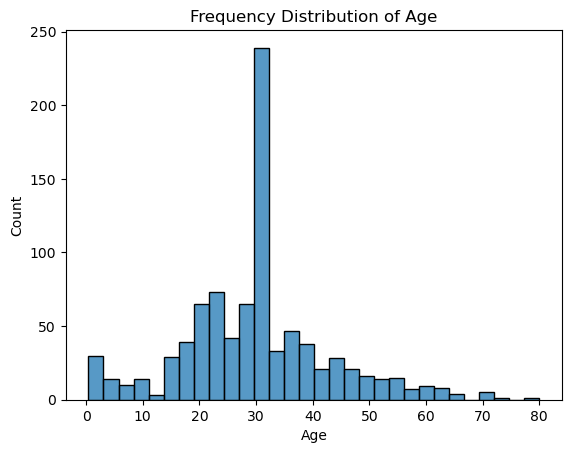

In [53]:
sns.histplot(df_titanic["Age"])
plt.title("Frequency Distribution of Age")
plt.show()

The histogram currently reflects the imputation of null values by the mean. Another approach is to impute using the hot decking approach so that the data data might be more distributed in alignment of the records that are not imputed. This approach imputes the value from the record that best matches the other known attribute values for the record with the missing value. This is achieved using sklearn.impute's KNNImputer Class. This replaces the missing value with the closest neighbor in the attribute space.

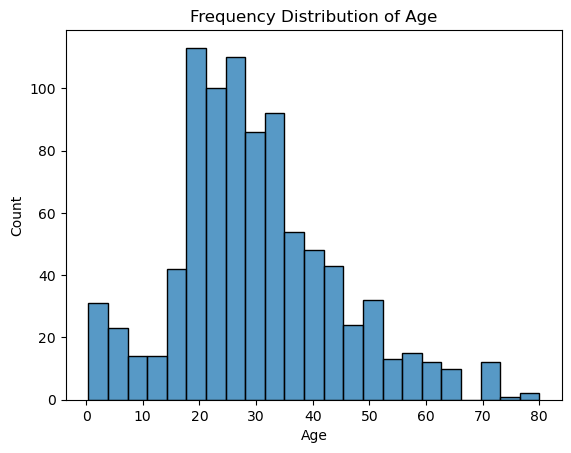

In [54]:
from sklearn.impute import KNNImputer

alt_titanic = pd.read_csv(data_path)

# Separate numeric and categorical
numeric_data = alt_titanic[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
categorical_data = pd.get_dummies(alt_titanic[['Sex', 'Embarked']], drop_first=True)

# Combine numeric and encoded categorical
imputer_input = pd.concat([numeric_data, categorical_data], axis=1)

# Impute
imputer = KNNImputer(n_neighbors=1)
imputed_array = imputer.fit_transform(imputer_input)

# Put back the 'Age' column
alt_titanic['Age'] = imputed_array[:, imputer_input.columns.get_loc('Age')]

sns.histplot(alt_titanic['Age'])
plt.title("Frequency Distribution of Age")
plt.show()

#### Bar plot of survival counts for sex values.

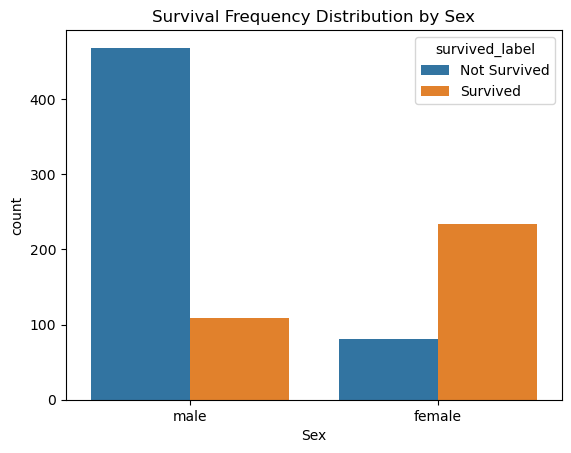

In [59]:
df_titanic['survived_label'] = alt_titanic['Survived'].map({0: 'Not Survived', 1: 'Survived'})
sns.countplot(data=df_titanic, x='Sex', hue='survived_label')
plt.title("Survival Frequency Distribution by Sex")
df_titanic.drop('survived_label', axis= 1, inplace= True)

#### Heatmap Showing Correlations Between Numerical Attributes

<Axes: >

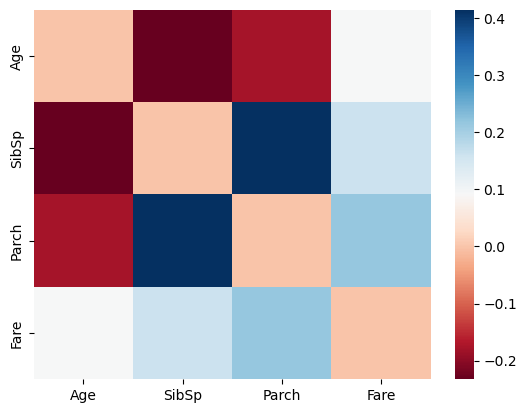

In [81]:
summary_table = overview["summary_table"]
numeric_attr = list(summary_table[(summary_table["data_type"]== "int64") | (summary_table["data_type"] == "float64")]["attribute"])
 # drops class attributes with numeric values 
df_numeric = df_titanic[numeric_attr].drop(["PassengerId","Survived","Pclass"], axis = 1)
corr_matrix = df_numeric.corr()
corr_matrix[corr_matrix == 1] = 0 # balances color range and "sinks" artificial correlation values

sns.heatmap(corr_matrix, cmap = 'RdBu')

Correlation is measured for numerical data and not categorical data using Pearson's Correlation. This is the default correlation used with the .corr() method in pandas. If the ordinal data were to be included, then Spearman's rank would be used. <br>

The correlation in the true numeric attributes are low overall which means the these attributes will not account for the same variation in the dataset overall which serves their contribution to certain types of machine learning modeling. The highest correlation occurs between age and the number of siblings/spouses each person has on board (indicated by the SibSp attribute), and between the number of parents/children each person has on board and siblings/spouses each person has on board. The latter correlated attributes have the strongest direct correlation which seems intuitive given the that the both account for the number of nuclear family members are on board with each person. The fact that they are not more correlated is likely due to the fact that they don't measure exactly the same thing- it seems conceivable that both siblings spouses can travel without children depending on age. It can also indicate inconsistency in reporting. Age and sibling/spouse have the strongest inverse correlation affirming the logical conclusion that the younger a person is, the more likely they are to be traveling with family. There is also noticeable correlation between age and parent/children which is consistent with the positive correlation between the parent/children and sibling/parent. This lesser correlation likely reflect the fact that the oldest passengers are the least likely to have a parent on board but also less likely to be traveling with children.

---

### Potential Future Analysis:

Further exploration could include the relationships between passenger class and number of nuclear family on board. Additionally, relationships between surviving and the number of nuclear family members or port of embarkation would be revealing about how decisions were made for the allocation of survival resources.